# Exploratory Data Analysis

This project analyzes the behavior of daily demand from a database extracted from Kaggle.

# Libraries used

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px 

from statsmodels.tsa.stattools import adfuller

# Import and transform the data

In [2]:
data = pd.read_csv("../data/sales_data.csv")
data.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [3]:
data.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

In [4]:
data.dtypes

Date                   object
Store ID               object
Product ID             object
Category               object
Region                 object
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Price                 float64
Discount                int64
Weather Condition      object
Promotion               int64
Competitor Pricing    float64
Seasonality            object
Epidemic                int64
Demand                  int64
dtype: object

In [51]:
copy_data = data.copy()
copy_data= copy_data.drop(['Date', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand'], axis=1)
for col in copy_data:
    print(f"{col}:{data[col].unique()}")

Store ID:['S001', 'S002', 'S003', 'S004', 'S005']
Categories (5, object): ['S001', 'S002', 'S003', 'S004', 'S005']
Product ID:['P0001', 'P0002', 'P0003', 'P0004', 'P0005', ..., 'P0016', 'P0017', 'P0018', 'P0019', 'P0020']
Length: 20
Categories (20, object): ['P0001', 'P0002', 'P0003', 'P0004', ..., 'P0017', 'P0018', 'P0019', 'P0020']
Category:['Electronics', 'Clothing', 'Groceries', 'Toys', 'Furniture']
Categories (5, object): ['Clothing', 'Electronics', 'Furniture', 'Groceries', 'Toys']
Region:['North', 'South', 'East', 'West']
Categories (4, object): ['East', 'North', 'South', 'West']
Price:[ 72.72  80.16  62.94 ... 184.11 120.56 144.42]
Discount:[ 5 15 10  0 25 20]
Weather Condition:['Snowy', 'Cloudy', 'Sunny', 'Rainy']
Categories (4, object): ['Cloudy', 'Rainy', 'Snowy', 'Sunny']
Promotion:[0 1]
Competitor Pricing:[ 85.73  92.02  60.08 ... 170.72 131.91 214.68]
Seasonality:['Winter', 'Spring', 'Summer', 'Autumn']
Categories (4, object): ['Autumn', 'Spring', 'Summer', 'Winter']
Epid

This dataset has variables as objects, but these are categorical or binary variables.

In [5]:
data['Date'] = pd.to_datetime(data['Date'])
categ_list =['Store ID', 'Product ID', 'Category', 'Region','Weather Condition','Seasonality']

for var in categ_list:
    data[var]= data[var].astype('category')

del(categ_list, var)

data.dtypes

Date                  datetime64[ns]
Store ID                    category
Product ID                  category
Category                    category
Region                      category
Inventory Level                int64
Units Sold                     int64
Units Ordered                  int64
Price                        float64
Discount                       int64
Weather Condition           category
Promotion                      int64
Competitor Pricing           float64
Seasonality                 category
Epidemic                       int64
Demand                         int64
dtype: object

**The dataset does not have a null values, and the data types are correct**

# EDA

The objective of this analysis is forecast the sales of the company, therefore, is a necessary identify the variables that affect the sales

Text(0.5, 1.0, 'Total sales')

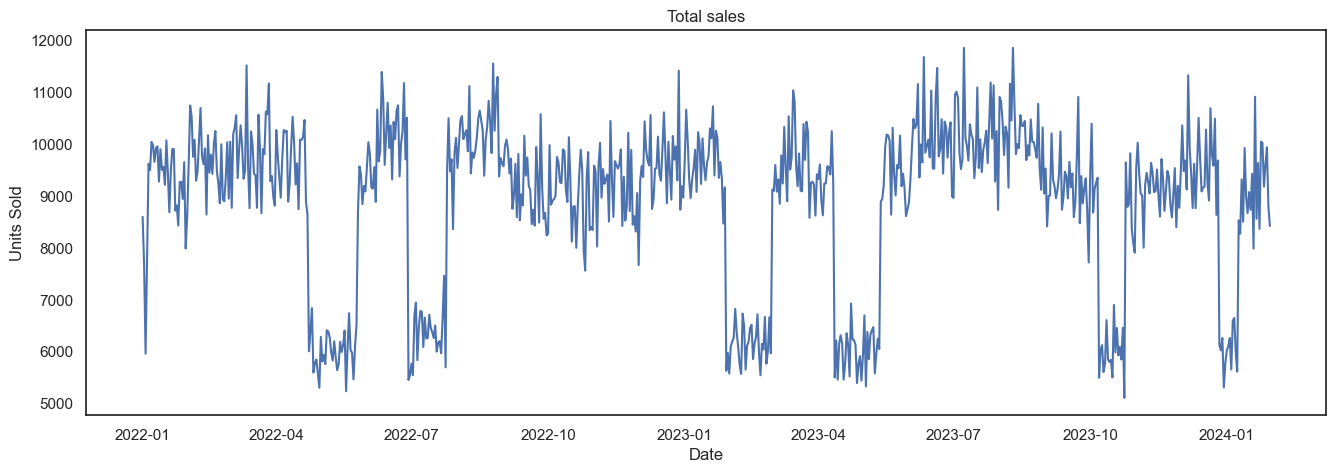

In [6]:
daily_sales = data.groupby('Date')['Units Sold'].sum()

sns.set_theme(style='white', palette='deep')

plt.figure(figsize=(16,5))
sns.lineplot(daily_sales)
plt.title('Total sales')

The sales appear to be stationary, this can be confirm whit the unit root test.

In [ ]:
result = adfuller(daily_sales)
print()

AttributeError: 'tuple' object has no attribute 'head'